## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement ([Reference](https://github.com/ga-bahrain/dsb-pt3-bahrain-2026/blob/main/modules/supervised-machine-learning/0.How%20to%20Frame%20a%20Data%20Science%20Problem/ML-Framing-a-Data-Science-Problem.pdf))
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : Loan Default Predection

## Problem Statement

Loan default is a major risk for financial institutions, as it can lead to significant financial losses. This project aims to build a Supervised Binary Classification model that predicts whether a borrower will default on a loan using demographic, financial, and loan-related information. The target variable is **Status**, where 0 represents a non-defaulted loan and 1 represents a defaulted loan.

## Data Info
Data Source : https://www.kaggle.com/datasets/yasserh/loan-default-dataset/data

## Data Dictionary

| Column                    | Type    | Description                                                                   |
| ------------------------- | ------- | ----------------------------------------------------------------------------- |
| ID                        | int64   | Unique identifier for each loan application                                   |
| year                      | int64   | Year in which the loan application was recorded                               |
| loan_limit                | str     | Loan limit category                                                           |
| Gender                    | str     | Gender of the borrower                                                        |
| approv_in_adv             | str     | Indicates whether the loan was approved in advance                            |
| loan_type                 | str     | Type of loan                                                                  |
| loan_purpose              | str     | Purpose of the loan                                                           |
| Credit_Worthiness         | str     | Borrower's creditworthiness category                                          |
| open_credit               | str     | Status of open credit accounts                                                |
| business_or_commercial    | str     | Indicates whether the loan is for business/commercial purposes                |
| loan_amount               | int64   | Total loan amount requested or approved                                       |
| rate_of_interest          | float64 | Interest rate applied to the loan                                             |
| Interest_rate_spread      | float64 | Difference between benchmark rate and loan interest rate                      |
| Upfront_charges           | float64 | Fees and charges paid at the beginning of the loan                            |
| term                      | float64 | Loan repayment term (months)                                                  |
| Neg_ammortization         | str     | Indicates whether negative amortization is allowed                            |
| interest_only             | str     | Indicates whether the borrower pays only interest for a period                |
| lump_sum_payment          | str     | Indicates whether a lump-sum payment option exists                            |
| property_value            | float64 | Estimated value of the property                                               |
| construction_type         | str     | Type of property construction                                                 |
| occupancy_type            | str     | Property occupancy classification                                             |
| Secured_by                | str     | Asset used to secure the loan                                                 |
| total_units               | str     | Number of units in the property                                               |
| income                    | float64 | Annual borrower income                                                        |
| credit_type               | str     | Credit bureau/provider type                                                   |
| Credit_Score              | int64   | Borrower's credit score                                                       |
| co-applicant_credit_type  | str     | Credit type of the co-applicant                                               |
| age                       | str     | Borrower's age group                                                          |
| submission_of_application | str     | Method used to submit the loan application                                    |
| LTV                       | float64 | Loan-to-Value ratio                                                           |
| Region                    | str     | Geographic region of the borrower/property                                    |
| Security_Type             | str     | Type of loan security                                                         |
| Status                    | int64   | **Target variable** indicating loan default status (0 = Non-Default, 1 = Default) |
| dtir1                     | float64 | Debt-to-Income Ratio (DTI)                                                    |


In [1]:
# start you EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loan = pd.read_csv('../Capstone_Project/1. Loan Default Predection/Loan_Default.csv')
loan.head(5)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


**Q1**: What is your target column and what does it represent?

**A1**: The target is to know if the loan will be default or not (Status column)

**Q2**: Is your target categorical or continuous? is it balanced (Plot the distribution)?

**A2**: The target is categorical (0 --> Non-default loans is 75.36% , 1 --> Default loans is 24.64%)

**Q3**: What types of features do you have (categorical / numerical)? how many of each ?

**A3**: 21 Categorical Features & 13 Numerics

**Q4**: How many null values does each feature have? what's your plan for each?

**A4**: 
| Feature                   | Missing Values | % Missing |
|------------------------- |-------------- |--------- |
| Upfront_charges           |         39,642 |    26.66% |
| Interest_rate_spread      |         36,639 |    24.64% |
| rate_of_interest          |         36,439 |    24.51% |
| dtir1                     |         24,121 |    16.22% |
| property_value            |         15,098 |    10.15% |
| LTV                       |         15,098 |    10.15% |
| income                    |          9,150 |     6.15% |
| loan_limit                |          3,344 |     2.25% |
| approv_in_adv             |            908 |     0.61% |
| age                       |            200 |     0.13% |
| submission_of_application |            200 |     0.13% |
| loan_purpose              |            134 |     0.09% |
| Neg_ammortization         |            121 |     0.08% |
| term                      |             41 |     0.03% |

**Plan to handle null values:**
- Numerical features = Impute using median
- Categorical features = Impute using mode (replace missing values with the most frequent value)

**Q5**: Which features are most correlated with your target, and with each other?

**A5**: 
- Positive correlation: dtir1 (Debt-to-Income Ratio) = 0.078, LTV (Loan-to-Value Ratio) = 0.039
- Negative correlation: income = -0.065, property_value = -0.049

**Q6**: Are there outliers? how would you handle them?
- income 6,546 rows (4.69%)
- property_value 5,266 rows (3.94%)
- Upfront_charges 2,880 rows (2.64%)

**Handling outliers:**
Will not do anything regarding the identified outliers because they appear to be valid observations. It is natural for some borrowers to have higher incomes, property values, and upfront charges, and removing them could result in the loss of important information.


In [3]:
loan.shape

(148670, 34)

In [4]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

In [5]:
loan['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

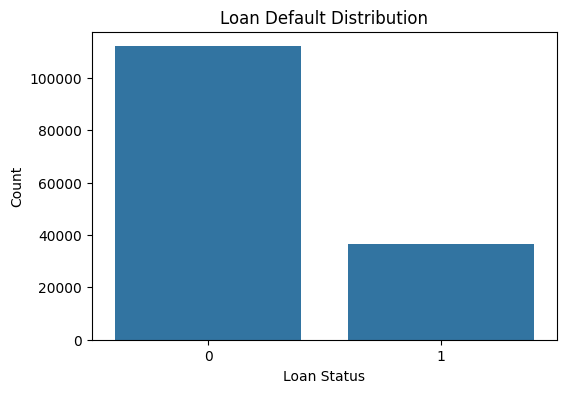

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Status', data=loan)

plt.title('Loan Default Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

In [7]:
loan.isnull().sum().sort_values(ascending=False)

Upfront_charges              39642
Interest_rate_spread         36639
rate_of_interest             36439
dtir1                        24121
property_value               15098
LTV                          15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
age                            200
submission_of_application      200
loan_purpose                   134
Neg_ammortization              121
term                            41
year                             0
ID                               0
business_or_commercial           0
open_credit                      0
lump_sum_payment                 0
interest_only                    0
loan_amount                      0
Gender                           0
loan_type                        0
Credit_Worthiness                0
occupancy_type                   0
construction_type                0
Credit_Score                     0
credit_type                      0
total_units         

In [8]:
loan.duplicated().sum()

np.int64(0)

In [9]:
corr = loan.select_dtypes(include=['int64','float64']).corr()
corr['Status'].sort_values(ascending=False)

Status                  1.000000
dtir1                   0.078083
LTV                     0.038895
rate_of_interest        0.022957
Credit_Score            0.004004
ID                      0.001703
term                   -0.000240
Upfront_charges        -0.019138
loan_amount            -0.036825
property_value         -0.048864
income                 -0.065119
year                         NaN
Interest_rate_spread         NaN
Name: Status, dtype: float64

In [10]:
numerical_cols = [
    'loan_amount',
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges',
    'property_value',
    'income',
    'Credit_Score',
    'LTV',
    'dtir1'
]

outlier_summary = []

for col in numerical_cols:
    data = loan[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data < lower) | (data > upper)]

    outlier_summary.append([
        col,
        len(outliers),
        round((len(outliers)/len(data))*100, 2)
    ])

outlier_loan = pd.DataFrame(
    outlier_summary,
    columns=['Feature', 'Outlier Count', 'Outlier %']
)

outlier_loan.sort_values('Outlier Count', ascending=False)

,Feature,Outlier Count,Outlier %
5,income,6546,4.69
4,property_value,5266,3.94
3,Upfront_charges,2880,2.64
8,dtir1,2013,1.62
0,loan_amount,1895,1.27
7,LTV,1882,1.41
1,rate_of_interest,856,0.76
2,Interest_rate_spread,445,0.40
6,Credit_Score,0,0.00


In [11]:
loan[['income','property_value','Upfront_charges']].describe()

,income,property_value,Upfront_charges
count,139520.000000,1.335720e+05,109028.000000
mean,6957.338876,4.978935e+05,3224.996127
std,6496.586382,3.599353e+05,3251.121510
min,0.000000,8.000000e+03,0.000000
25%,3720.000000,2.680000e+05,581.490000
50%,5760.000000,4.180000e+05,2596.450000
75%,8520.000000,6.280000e+05,4812.500000
max,578580.000000,1.650800e+07,60000.000000


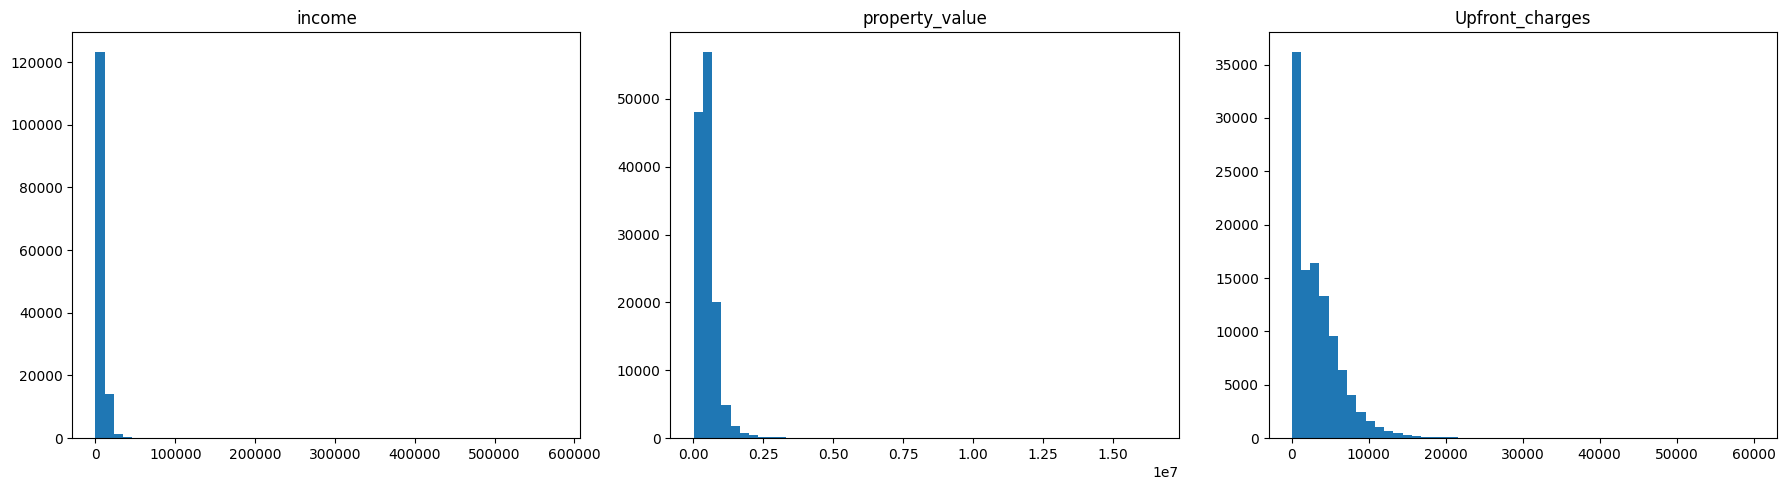

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

columns = ['income', 'property_value', 'Upfront_charges']

for i, col in enumerate(columns):
    axes[i].hist(loan[col].dropna(), bins=50)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Topic 2 : Hospital Readmission Prediction

## Problem Statement

Hospitals aim to reduce patient readmissions, as repeated admissions increase healthcare costs and may indicate inadequate treatment or follow-up care. This project aims to develop a Supervised Binary Classification model that predicts whether a diabetic patient will be readmitted after discharge based on demographic, clinical, and treatment-related information.

## Data Info
Data Source : https://www.kaggle.com/datasets/abdelazizsami/diabetes-130-us-hospitals-for-years-1999-2008?select=diabetic_data.csv

## Data Dictionary

| Column | Type | Description |
| -------- | ------- | ------- |
| encounter_id | int64 | Unique identifier for each hospital encounter |
| patient_nbr | int64 | Unique identifier for each patient |
| race | str | Patient race category |
| gender | str | Patient gender |
| age | str | Patient age group |
| weight | str | Patient weight category |
| admission_type_id | int64 | Type of hospital admission |
| discharge_disposition_id | int64 | Patient discharge status/type |
| admission_source_id | int64 | Source of hospital admission |
| time_in_hospital | int64 | Number of days the patient stayed in hospital |
| payer_code | str | Insurance or payer category |
| medical_specialty | str | Medical specialty of the treating physician |
| num_lab_procedures | int64 | Number of lab procedures performed |
| num_procedures | int64 | Number of medical procedures performed |
| num_medications | int64 | Number of medications given |
| number_outpatient | int64 | Number of outpatient visits before this encounter |
| number_emergency | int64 | Number of emergency visits before this encounter |
| number_inpatient | int64 | Number of inpatient visits before this encounter |
| diag_1 | str | Primary diagnosis code |
| diag_2 | str | Secondary diagnosis code |
| diag_3 | str | Additional diagnosis code |
| number_diagnoses | int64 | Number of diagnoses recorded |
| max_glu_serum | str | Maximum glucose serum test result |
| A1Cresult | str | A1C test result |
| metformin | str | Change/status of metformin medication |
| repaglinide | str | Change/status of repaglinide medication |
| nateglinide | str | Change/status of nateglinide medication |
| chlorpropamide | str | Change/status of chlorpropamide medication |
| glimepiride | str | Change/status of glimepiride medication |
| acetohexamide | str | Change/status of acetohexamide medication |
| glipizide | str | Change/status of glipizide medication |
| glyburide | str | Change/status of glyburide medication |
| tolbutamide | str | Change/status of tolbutamide medication |
| pioglitazone | str | Change/status of pioglitazone medication |
| rosiglitazone | str | Change/status of rosiglitazone medication |
| acarbose | str | Change/status of acarbose medication |
| miglitol | str | Change/status of miglitol medication |
| troglitazone | str | Change/status of troglitazone medication |
| tolazamide | str | Change/status of tolazamide medication |
| examide | str | Change/status of examide medication |
| citoglipton | str | Change/status of citoglipton medication |
| insulin | str | Change/status of insulin medication |
| glyburide-metformin | str | Change/status of glyburide-metformin medication |
| glipizide-metformin | str | Change/status of glipizide-metformin medication |
| glimepiride-pioglitazone | str | Change/status of glimepiride-pioglitazone medication |
| metformin-rosiglitazone | str | Change/status of metformin-rosiglitazone medication |
| metformin-pioglitazone | str | Change/status of metformin-pioglitazone medication |
| change | str | Indicates whether diabetes medication was changed |
| diabetesMed | str | Indicates whether diabetes medication was prescribed |
| readmitted | str | **Target variable** showing readmission status: NO, >30, or <30 |


In [13]:
diabetics = pd.read_csv('../Capstone_Project/2. Diabetes 130-US Hospitals for Years 1999-2008/diabetic_data.csv')
diabetics.sample(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
48324,147572634,35715528,Caucasian,Female,[70-80),?,1,3,7,4,...,No,No,No,No,No,No,No,No,Yes,<30
89734,290531304,42095655,Caucasian,Female,[60-70),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,NO
45557,140815656,40813686,Caucasian,Male,[70-80),?,3,1,1,3,...,No,No,No,No,No,No,No,No,No,NO
18315,66434106,877590,Caucasian,Male,[50-60),?,3,1,1,1,...,No,No,No,No,No,No,No,No,Yes,>30
72658,213157530,100598301,Caucasian,Female,[80-90),?,1,3,7,5,...,No,Steady,No,No,No,No,No,Ch,Yes,<30


**Q1**: What is your target column and what does it represent?

**A1**: The target (readmitted column) is to know whether a diabetic patient will be readmitted to the hospital after discharge.
        Note that the readmitted column will be replaced to binary categorical in the preprocessing phase

**Q2**: Is your target categorical or continuous? is it balanced (Plot the distribution)?

**A2**: The target is categorical after converting >30 and <30 to 0 and NO to 1 (0 --> Not readmitted is 53.91% , 1 --> Readmitted is 46.09%)

**Q3**: What types of features do you have (categorical / numerical)? how many of each ?

**A3**: 37 Categorical Features & 13 Numerics

**Q4**: How many null values does each feature have? what's your plan for each?

**A4**: 
| Feature           | Missing Values | Missing % |
| ----------------- | -------------: | --------: |
| weight            |         98,569 |    96.86% |
| max_glu_serum     |         96,420 |    94.75% |
| A1Cresult         |         84,748 |    83.28% |
| medical_specialty |         49,949 |    49.08% |
| payer_code        |         40,256 |    39.56% |
| race              |          2,273 |     2.23% |
| diag_3            |          1,423 |     1.40% |
| diag_2            |            358 |     0.35% |
| diag_1            |             21 |     0.02% |


**Plan to handle null values:**
- For weight, max_glu_serum and A1Cresult = Drop the column due to excessive missing values
- For medical_specialty and payer_code = Replace missing values with 'Unknown'
- For race, diag_1, diag_2 and diag_3 = Impute using mode (replace missing values with the most frequent value)

**Q5**: Which features are most correlated with your target, and with each other?

**A5**: Since the target column (readmitted) is categorical correlation will be done later on the preprocessing phase, instead, checked the correlation between numeric features:

| Feature 1          | Feature 2          | Correlation |
| ------------------ | ------------------ | ----------  |
| time_in_hospital   | num_medications    |       0.466 |
| num_medications    | num_procedures     |       0.386 |
| time_in_hospital   | num_lab_procedures |       0.318 |
| num_lab_procedures | num_medications    |       0.268 |
| number_emergency   | number_inpatient   |       0.267 |
| number_diagnoses   | num_medications    |       0.262 |


**Q6**: Are there outliers? how would you handle them?

| Feature            | Outlier Count      | Outlier %  |
| ------------------ | ------------------ | ---------- |
| number_outpatient	 | 16739	          | 16.45      |
| number_emergency	 | 11383	          | 11.19      |
| number_inpatient	 | 7049	              | 6.93       |
| num_procedures	 | 4954	              | 4.87       |
| num_medications	 | 2557	              | 2.51       |
| time_in_hospital	 | 2252	              | 2.21       |
| number_diagnoses	 | 281	              | 0.28       |
| num_lab_procedures | 143	              | 0.14       |

**Handling outliers:**
Will not do anything regarding the identified outliers because they appear to be valid observations. It is reasonable for some patients to have a higher number of outpatient visits, emergency visits, inpatient admissions, medications, or longer hospital stays.


In [14]:
diabetics.shape

(101766, 50)

In [15]:
diabetics.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [16]:
diabetics['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [17]:
(diabetics == '?').sum().sort_values(ascending=False).head(10)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
admission_type_id        0
patient_nbr              0
encounter_id             0
dtype: int64

In [18]:
diabetics = diabetics.replace('?', pd.NA)

In [19]:
diabetics.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [20]:
diabetics.duplicated().sum()

np.int64(0)

In [21]:
pd.crosstab(diabetics['age'], diabetics['readmitted'])

readmitted,<30,>30,NO
age,,,
[0-10),3,26,132
[10-20),40,224,427
[20-30),236,510,911
[30-40),424,1187,2164
[40-50),1027,3278,5380
[50-60),1668,5917,9671
[60-70),2502,7897,12084
[70-80),3069,9475,13524
[80-90),2078,6223,8896


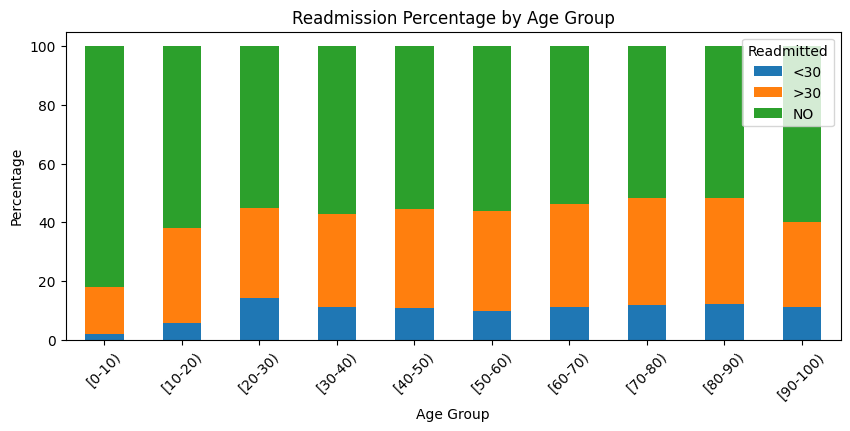

In [22]:
age_readmission_pct = pd.crosstab(
    diabetics['age'],
    diabetics['readmitted'],
    normalize='index'
) * 100

age_readmission_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,4)
)

plt.title('Readmission Percentage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.legend(title='Readmitted')
plt.xticks(rotation=45)

plt.show()

In [23]:
pd.crosstab(diabetics['gender'], diabetics['readmitted'])

readmitted,<30,>30,NO
gender,,,
Female,6152,19518,29038
Male,5205,16027,25823
Unknown/Invalid,0,0,3


In [24]:
pd.crosstab(diabetics['diabetesMed'], diabetics['readmitted'])

readmitted,<30,>30,NO
diabetesMed,,,
No,2246,7227,13930
Yes,9111,28318,40934


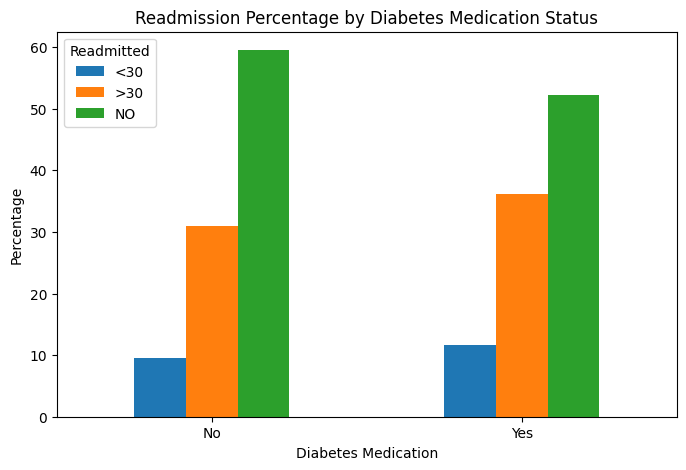

In [25]:
diabetesMed_readmission_pct = pd.crosstab(
    diabetics['diabetesMed'],
    diabetics['readmitted'],
    normalize='index'
) * 100

diabetesMed_readmission_pct.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Readmission Percentage by Diabetes Medication Status')
plt.xlabel('Diabetes Medication')
plt.ylabel('Percentage')
plt.legend(title='Readmitted')
plt.xticks(rotation=0)

plt.show()

In [26]:
diabetics.groupby('readmitted')['time_in_hospital'].mean()

readmitted
<30    4.768249
>30    4.495541
NO     4.254429
Name: time_in_hospital, dtype: float64

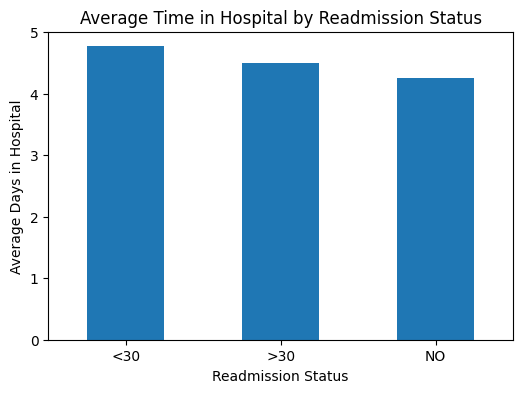

In [27]:
diabetics.groupby('readmitted')['time_in_hospital'].mean().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Time in Hospital by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Average Days in Hospital')
plt.xticks(rotation=0)

plt.show()

In [28]:
diabetics.groupby('readmitted')['number_inpatient'].mean()

readmitted
<30    1.224003
>30    0.838993
NO     0.381963
Name: number_inpatient, dtype: float64

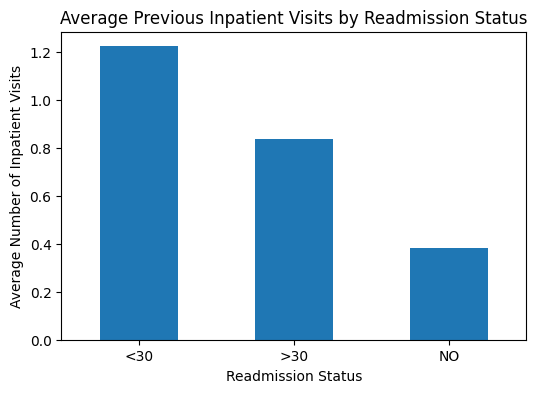

In [29]:
diabetics.groupby('readmitted')['number_inpatient'].mean().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Previous Inpatient Visits by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Average Number of Inpatient Visits')
plt.xticks(rotation=0)

plt.show()

In [30]:
corr = diabetics.select_dtypes(include=['int64','float64']).corr()
corr.unstack().sort_values(ascending=False).drop_duplicates().head(20)

encounter_id        encounter_id                1.000000
                    patient_nbr                 0.512028
time_in_hospital    num_medications             0.466135
num_medications     num_procedures              0.385767
time_in_hospital    num_lab_procedures          0.318450
num_lab_procedures  num_medications             0.268161
number_emergency    number_inpatient            0.266559
encounter_id        number_diagnoses            0.265149
number_diagnoses    num_medications             0.261526
                    patient_nbr                 0.226847
                    time_in_hospital            0.220186
num_procedures      time_in_hospital            0.191472
time_in_hospital    discharge_disposition_id    0.162748
num_lab_procedures  number_diagnoses            0.152773
admission_type_id   num_procedures              0.129888
num_medications     discharge_disposition_id    0.108753
number_outpatient   number_inpatient            0.107338
admission_type_id   admission_s

In [31]:
numerical_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

outlier_summary = []

for col in numerical_cols:

    Q1 = diabetics[col].quantile(0.25)
    Q3 = diabetics[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = diabetics[(diabetics[col] < lower) | (diabetics[col] > upper)]

    outlier_summary.append([
        col,
        len(outliers),
        round((len(outliers) / len(diabetics)) * 100, 2)
    ])

outlier_diabetics = pd.DataFrame(
    outlier_summary,
    columns=['Feature', 'Outlier Count', 'Outlier %']
)

outlier_diabetics.sort_values('Outlier Count', ascending=False)

,Feature,Outlier Count,Outlier %
4,number_outpatient,16739,16.45
5,number_emergency,11383,11.19
6,number_inpatient,7049,6.93
2,num_procedures,4954,4.87
3,num_medications,2557,2.51
0,time_in_hospital,2252,2.21
7,number_diagnoses,281,0.28
1,num_lab_procedures,143,0.14


# Topic 3 : Customer Churn Prediction

## Problem Statement

Customer churn is a major challenge for e-commerce businesses because losing existing customers can reduce revenue and increase customer acquisition costs. This project aims to develop a Supervised Binary Classification model that predicts whether a customer is likely to churn based on demographic information, purchasing behavior, engagement metrics, and platform usage patterns.

## Data Info
Data Source : https://www.kaggle.com/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset

## Data Dictionary

| Column | Type | Description |
| -------- | ------- | ------- |
| Age | float64 | Customer age |
| Gender | str | Customer gender |
| Country | str | Customer country of residence |
| City | str | Customer city of residence |
| Membership_Years | float64 | Number of years the customer has been a member |
| Login_Frequency | float64 | Frequency of customer logins |
| Session_Duration_Avg | float64 | Average duration of customer sessions |
| Pages_Per_Session | float64 | Average number of pages viewed per session |
| Cart_Abandonment_Rate | float64 | Percentage of shopping carts abandoned before purchase |
| Wishlist_Items | float64 | Number of items saved in the wishlist |
| Total_Purchases | float64 | Total number of purchases made by the customer |
| Average_Order_Value | float64 | Average value of customer orders |
| Days_Since_Last_Purchase | float64 | Number of days since the customer's last purchase |
| Discount_Usage_Rate | float64 | Percentage of purchases made using discounts |
| Returns_Rate | float64 | Percentage of purchased items returned |
| Email_Open_Rate | float64 | Percentage of marketing emails opened by the customer |
| Customer_Service_Calls | float64 | Number of customer service calls made |
| Product_Reviews_Written | float64 | Number of product reviews written by the customer |
| Social_Media_Engagement_Score | float64 | Customer engagement score on social media platforms |
| Mobile_App_Usage | float64 | Level of customer activity on the mobile application |
| Payment_Method_Diversity | float64 | Number of different payment methods used by the customer |
| Lifetime_Value | float64 | Total revenue generated by the customer over their lifetime |
| Credit_Balance | float64 | Customer's available credit balance |
| Churned | int64 | **Target Variable:** Indicates whether the customer has churned (0 = Retained, 1 = Churned) |
| Signup_Quarter | str | Quarter in which the customer signed up (Q1, Q2, Q3, Q4) |

In [32]:
ecom = pd.read_csv('../Capstone_Project/3. Ecommerce Customer Behavior/ecommerce_customer_churn_dataset.csv')
ecom.sample(5)

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
32656,45.0,Male,USA,Los Angeles,2.1,25.0,49.3,12.3,24.1,7.0,...,43.7,3.0,6.0,31.8,NaN,1.0,3144.72,3811.0,0,Q2
36612,50.0,Female,Canada,Calgary,2.1,12.0,35.2,11.9,44.6,7.0,...,29.3,5.0,4.0,31.9,27.8,2.0,3733.97,2081.0,0,Q4
25965,NaN,Other,UK,Leeds,3.1,24.0,40.4,12.6,62.7,5.0,...,36.5,4.0,NaN,47.0,34.4,NaN,2105.80,NaN,0,Q2
49473,34.0,Male,India,Hyderabad,1.4,2.0,7.6,3.6,68.1,0.0,...,0.0,8.0,1.0,7.8,6.2,2.0,1191.66,1502.0,1,Q1
12089,18.0,Female,USA,Los Angeles,1.0,14.0,38.8,7.6,47.6,5.0,...,45.3,7.0,0.0,33.0,16.8,3.0,2216.86,NaN,1,Q3


**Q1**: What is your target column and what does it represent?

**A1**: The target is to know if the customer will stop using the e-commerce platform or not (Churned column)

**Q2**: Is your target categorical or continuous? is it balanced (Plot the distribution)?

**A2**: The target is categorical (0 --> Not Churned is 71.1% , 1 --> Churned is 28.9%)

**Q3**: What types of features do you have (categorical / numerical)? how many of each ?

**A3**: 4 Categorical Features & 21 Numerics

**Q4**: How many null values does each feature have? what's your plan for each?

**A4**: 
| Feature                       | Missing Values | % Missing |
| ----------------------------- | -------------: | --------: |
| Social_Media_Engagement_Score |          6,000 |    12.00% |
| Credit_Balance                |          5,500 |    11.00% |
| Mobile_App_Usage              |          5,000 |    10.00% |
| Returns_Rate                  |          4,491 |     8.98% |
| Wishlist_Items                |          4,000 |     8.00% |
| Product_Reviews_Written       |          3,500 |     7.00% |
| Discount_Usage_Rate           |          3,500 |     7.00% |
| Session_Duration_Avg          |          3,399 |     6.80% |
| Pages_Per_Session             |          3,000 |     6.00% |
| Days_Since_Last_Purchase      |          3,000 |     6.00% |
| Email_Open_Rate               |          2,528 |     5.06% |
| Payment_Method_Diversity      |          2,500 |     5.00% |
| Age                           |          2,495 |     4.99% |
| Customer_Service_Calls        |            168 |     0.34% |


**Plan to handle null values:**
- Numerical features = Impute using median --> Need to be evaluated in preprocessing phase

**Q5**: Which features are most correlated with your target, and with each other?

**A5**: 
- Positive correlation: Customer_Service_Calls = 0.291, Cart_Abandonment_Rate = 0.278, Days_Since_Last_Purchase = 0.153
- Negative correlation: Pages_Per_Session = -0.232, Session_Duration_Avg = -0.228, Mobile_App_Usage = -0.223, Email_Open_Rate = -0.222, Login_Frequency = -0.204

**Q6**: Are there outliers? how would you handle them?

| Feature                  | Outlier Count | Outlier % |
| ------------------------ | ------------: | --------: |
| Payment_Method_Diversity |         2,439 |     5.13% |
| Days_Since_Last_Purchase |         2,313 |     4.92% |
| Lifetime_Value           |         1,684 |     3.37% |
| Membership_Years         |         1,581 |     3.16% |
| Returns_Rate             |         1,204 |     2.65% |
| Customer_Service_Calls   |         1,185 |     2.38% |
| Product_Reviews_Written  |         1,090 |     2.34% |
| Average_Order_Value      |         1,005 |     2.01% |


**Handling outliers:**
Will not do anything regarding the identified outliers because they appear to be valid observations. It is natural for some customers to have significantly higher lifetime values, longer membership durations, or longer periods between purchases.

In [33]:
ecom.shape

(50000, 25)

In [34]:
ecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

In [35]:
ecom['Churned'].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

In [36]:
ecom['Churned'].value_counts(normalize=True) * 100

Churned
0    71.1
1    28.9
Name: proportion, dtype: float64

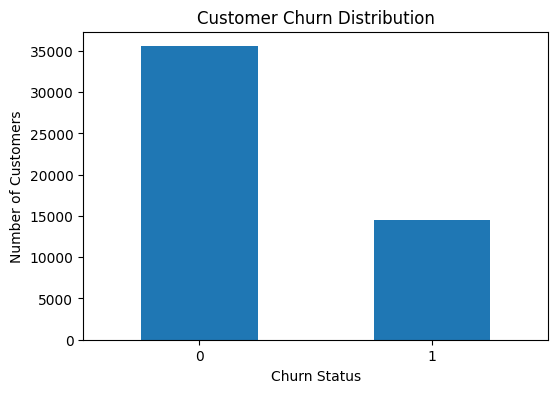

In [37]:
ecom['Churned'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

In [38]:
ecom.isnull().sum().sort_values(ascending=False)

Social_Media_Engagement_Score    6000
Credit_Balance                   5500
Mobile_App_Usage                 5000
Returns_Rate                     4491
Wishlist_Items                   4000
Product_Reviews_Written          3500
Discount_Usage_Rate              3500
Session_Duration_Avg             3399
Pages_Per_Session                3000
Days_Since_Last_Purchase         3000
Email_Open_Rate                  2528
Payment_Method_Diversity         2500
Age                              2495
Customer_Service_Calls            168
Gender                              0
Country                             0
Membership_Years                    0
Cart_Abandonment_Rate               0
Login_Frequency                     0
City                                0
Average_Order_Value                 0
Total_Purchases                     0
Lifetime_Value                      0
Churned                             0
Signup_Quarter                      0
dtype: int64

In [39]:
ecom.duplicated().sum()

np.int64(0)

In [40]:
corr = ecom.select_dtypes(include=['int64','float64']).corr()
corr['Churned'].sort_values(ascending=False)

Churned                          1.000000
Customer_Service_Calls           0.291103
Cart_Abandonment_Rate            0.277963
Days_Since_Last_Purchase         0.153360
Returns_Rate                     0.054189
Average_Order_Value              0.042288
Payment_Method_Diversity         0.004524
Membership_Years                -0.000623
Lifetime_Value                  -0.010684
Discount_Usage_Rate             -0.077121
Age                             -0.102849
Credit_Balance                  -0.156921
Total_Purchases                 -0.160029
Product_Reviews_Written         -0.181225
Social_Media_Engagement_Score   -0.191792
Wishlist_Items                  -0.197708
Login_Frequency                 -0.204379
Email_Open_Rate                 -0.222213
Mobile_App_Usage                -0.222876
Session_Duration_Avg            -0.228010
Pages_Per_Session               -0.231799
Name: Churned, dtype: float64

In [41]:
corr_matrix = ecom.select_dtypes(include=['int64','float64']).corr().abs()

high_corr = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

high_corr.head(15)

Session_Duration_Avg   Pages_Per_Session                0.756304
                       Mobile_App_Usage                 0.755931
Pages_Per_Session      Mobile_App_Usage                 0.724334
Login_Frequency        Session_Duration_Avg             0.703510
Session_Duration_Avg   Cart_Abandonment_Rate            0.698464
Login_Frequency        Pages_Per_Session                0.675544
                       Mobile_App_Usage                 0.674695
Session_Duration_Avg   Wishlist_Items                   0.669644
Cart_Abandonment_Rate  Mobile_App_Usage                 0.669626
Session_Duration_Avg   Email_Open_Rate                  0.669150
Pages_Per_Session      Cart_Abandonment_Rate            0.668503
Session_Duration_Avg   Total_Purchases                  0.662249
                       Social_Media_Engagement_Score    0.657871
Wishlist_Items         Mobile_App_Usage                 0.643101
Pages_Per_Session      Wishlist_Items                   0.640816
dtype: float64

In [42]:
numerical_cols = ecom.select_dtypes(include=['int64','float64']).columns

outlier_summary = []

for col in numerical_cols:
    data = ecom[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data < lower) | (data > upper)]

    outlier_summary.append([
        col,
        len(outliers),
        round((len(outliers)/len(data))*100, 2)
    ])

outlier_ecom = pd.DataFrame(
    outlier_summary,
    columns=['Feature', 'Outlier Count', 'Outlier %']
)

outlier_ecom.sort_values('Outlier Count', ascending=False)

,Feature,Outlier Count,Outlier %
17,Payment_Method_Diversity,2439,5.13
9,Days_Since_Last_Purchase,2313,4.92
18,Lifetime_Value,1684,3.37
1,Membership_Years,1581,3.16
11,Returns_Rate,1204,2.65
13,Customer_Service_Calls,1185,2.38
14,Product_Reviews_Written,1090,2.34
8,Average_Order_Value,1005,2.01
6,Wishlist_Items,858,1.87
7,Total_Purchases,628,1.26


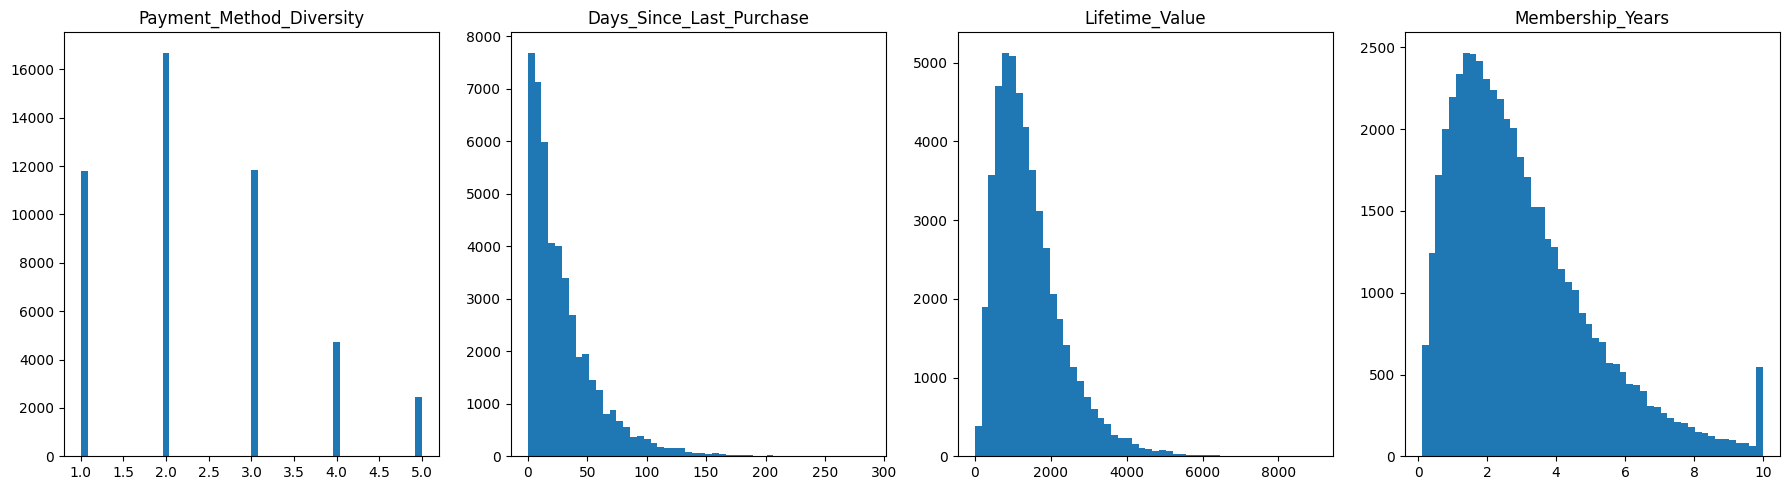

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

columns = [
    'Payment_Method_Diversity',
    'Days_Since_Last_Purchase',
    'Lifetime_Value',
    'Membership_Years'
]

for i, col in enumerate(columns):
    axes[i].hist(ecom[col].dropna(), bins=50)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()